# Iris Flower Classification using Machine Learning

## Project Overview
This project develops a machine learning classification model to identify iris flower species using flower measurements.

The dataset contains:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target classes are:
- Setosa
- Versicolor
- Virginica

The project includes:
- Data exploration
- Data visualization
- Model training
- Model evaluation
- Performance analysis

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

plt.style.use('default')
sns.set_theme(style="whitegrid")

# Loading the Dataset

The Iris dataset is loaded directly from Scikit-learn.

### Load Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target
df['species'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


# Dataset Information and Statistical Summary

### Dataset Info

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Class Distribution

This visualization shows the number of samples available for each iris species.

### Class Distribution Plot

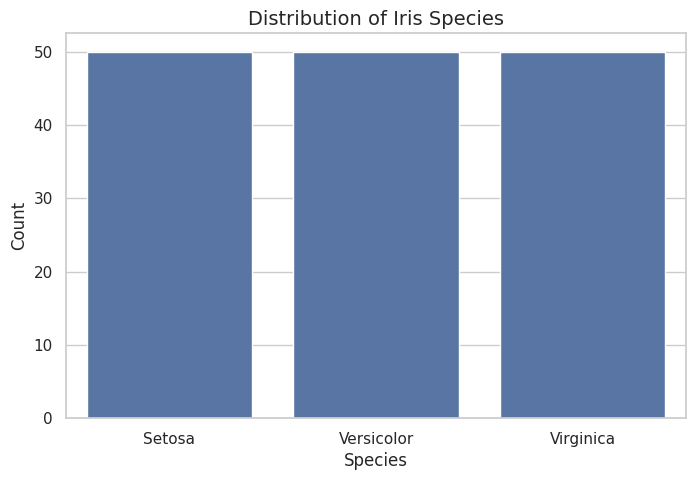

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='species'
)

plt.title('Distribution of Iris Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Count')

plt.show()

# Pairwise Feature Relationships

The pairplot helps visualize relationships between flower measurements across different species.

### Pairplot

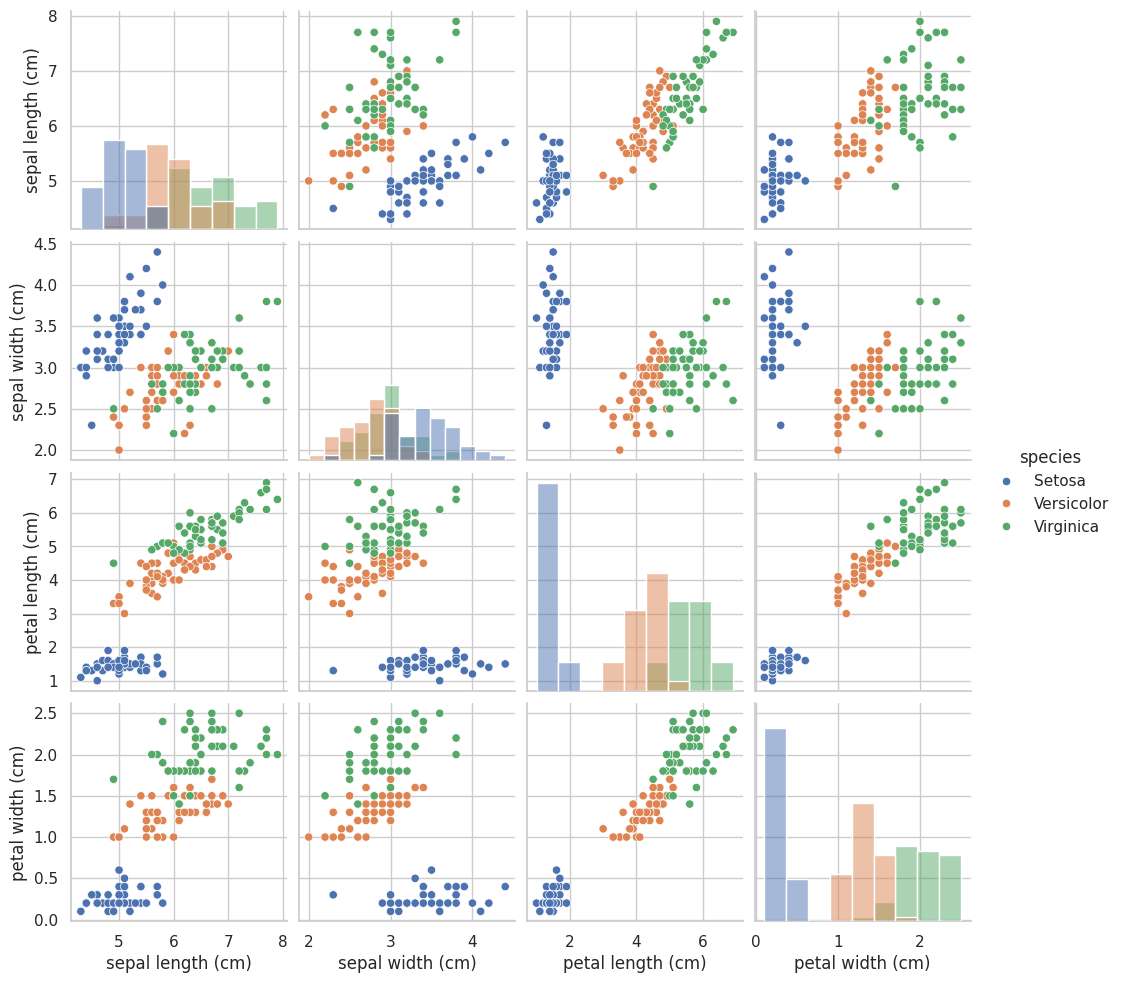

In [5]:
sns.pairplot(
    df,
    hue='species',
    diag_kind='hist'
)

plt.show()

# Correlation Heatmap

The heatmap highlights relationships between numerical features.

### Heatmap

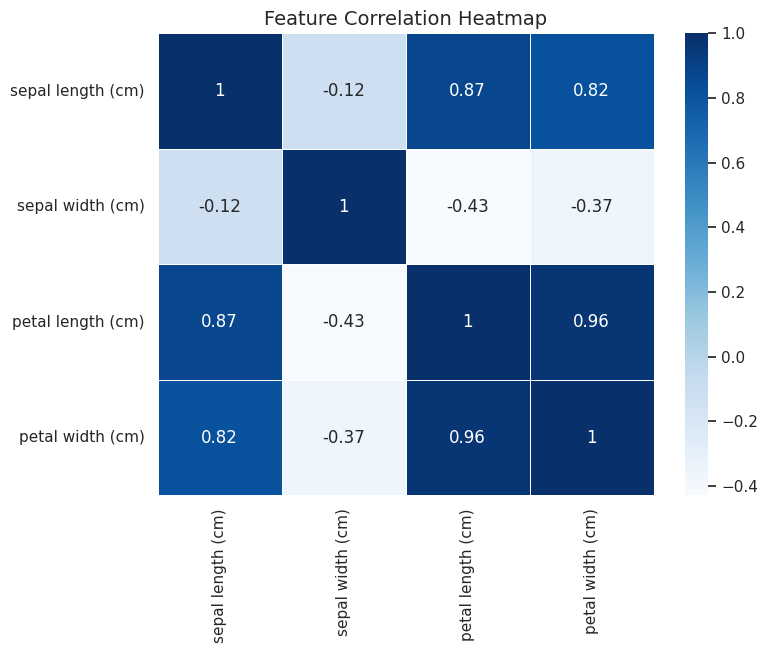

In [6]:
plt.figure(figsize=(8,6))

corr = df.drop('species', axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap', fontsize=14)

plt.show()

# Preparing Data for Machine Learning

The dataset is divided into:
- Features (X)
- Target labels (y)

The data is then split into training and testing sets.

### Feature Preparation

In [7]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

Standardization improves model consistency and performance.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

A Random Forest Classifier is used for iris species classification.

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

# Model Prediction and Evaluation

In [10]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:")
print(round(accuracy * 100, 2), "%")

Model Accuracy:
90.0 %


# Classification Report

In [11]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



# Confusion Matrix

The confusion matrix visualizes prediction performance for each species class.

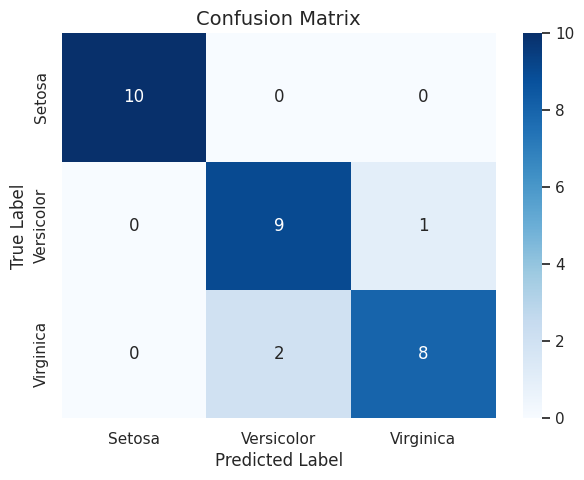

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix', fontsize=14)

plt.show()

# Feature Importance Analysis

Feature importance identifies which flower measurements contribute most to classification performance.

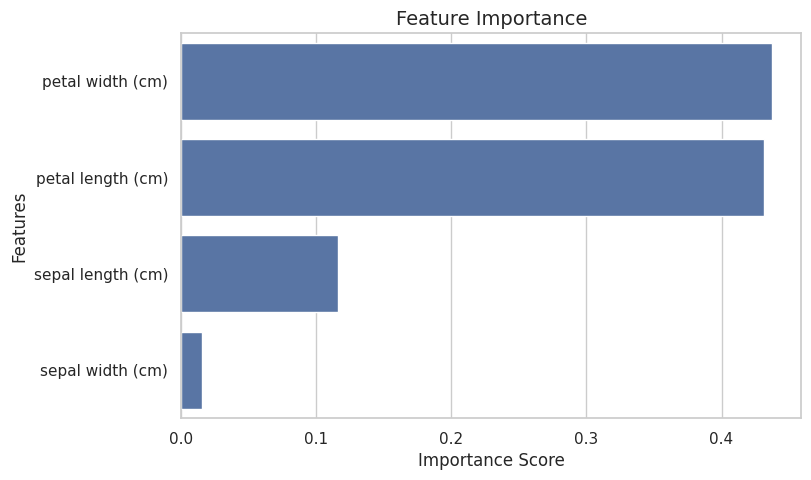

In [13]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

# Conclusion

The machine learning model successfully classified iris flower species using flower measurements.

Key outcomes:
- The Random Forest model achieved high classification accuracy.
- Petal dimensions contributed most strongly to classification.
- The dataset showed clear separation between species.

This project demonstrates the practical application of supervised machine learning for classification problems.